---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

<h1 style="text-align:center;">SHGR: A Generalized Maximal Correlation Coefficient</h1>

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

**Abstract**: *Traditional correlation measures, such as Pearson’s and Spearman’s coefficients, are limited in their ability to capture complex relationships, particularly nonlinear and multivariate dependencies. The Hirschfeld–Gebelein–Rényi (HGR) maximal correlation offers a powerful alternative by measuring the highest Pearson correlation achievable through nonlinear transformations of two random variables. However, estimating the HGR coefficient remains challenging due to the complexity of optimizing arbitrary nonlinear functions. We introduce a new coefficient, satisfying Rényi's axioms, based on the extension of HGR with Spearman's rank correlation: the Spearman HGR (SHGR). We propose a neural network-based estimator tailored to estimate (i) the bivariate correlation matrix, (ii) the multivariate correlations between a set of variables and another one, and (iii) the full correlation between two sets of variables. This estimate effectively detects nonlinear dependencies and demonstrates robustness to noise, outliers, and spurious correlations ("hallucinations"). Additionally, it achieves competitive computational efficiency through designed neural architectures. Comprehensive numerical experiments and feature selection tasks confirm that SHGR outperforms existing state-of-the-art methods.*

# Environment Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch import optim
from torch.utils.data import DataLoader, TensorDataset
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)
import torchsort

In [2]:
import numpy as np
import pandas as pd
import os
import copy
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import gaussian_kde, spearmanr, pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 7, 5
sns.set(rc={'figure.figsize':(7,5)})
sns.set(rc={'figure.figsize':(7,5)})
np.random.seed(42)
from tqdm import trange
import time
import subprocess
import random
import warnings
from ucimlrepo import fetch_ucirepo 
from maxcorr import indicator

**Import SHGR functions and competitors**

In [3]:
from src.SHGR import *
from src.Benchmark import *

**Repo for outputs and R competitors**

In [4]:
rep = os.getcwd()+"\\Results\\"

In [5]:
rep_pyToR = rep + 'pyToR/'

In [6]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
device

device(type='cuda')

# Data

## Numerical with Bivariate Nonlinear Relationships

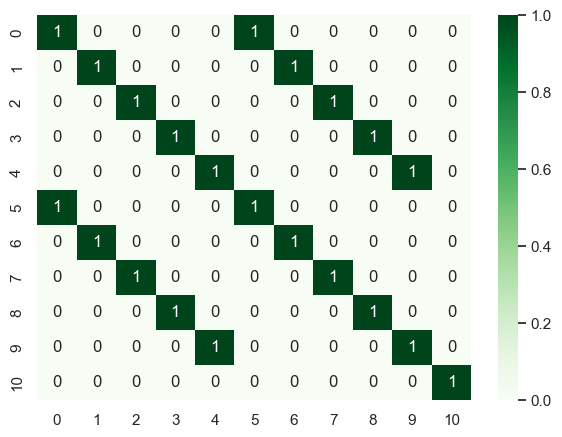

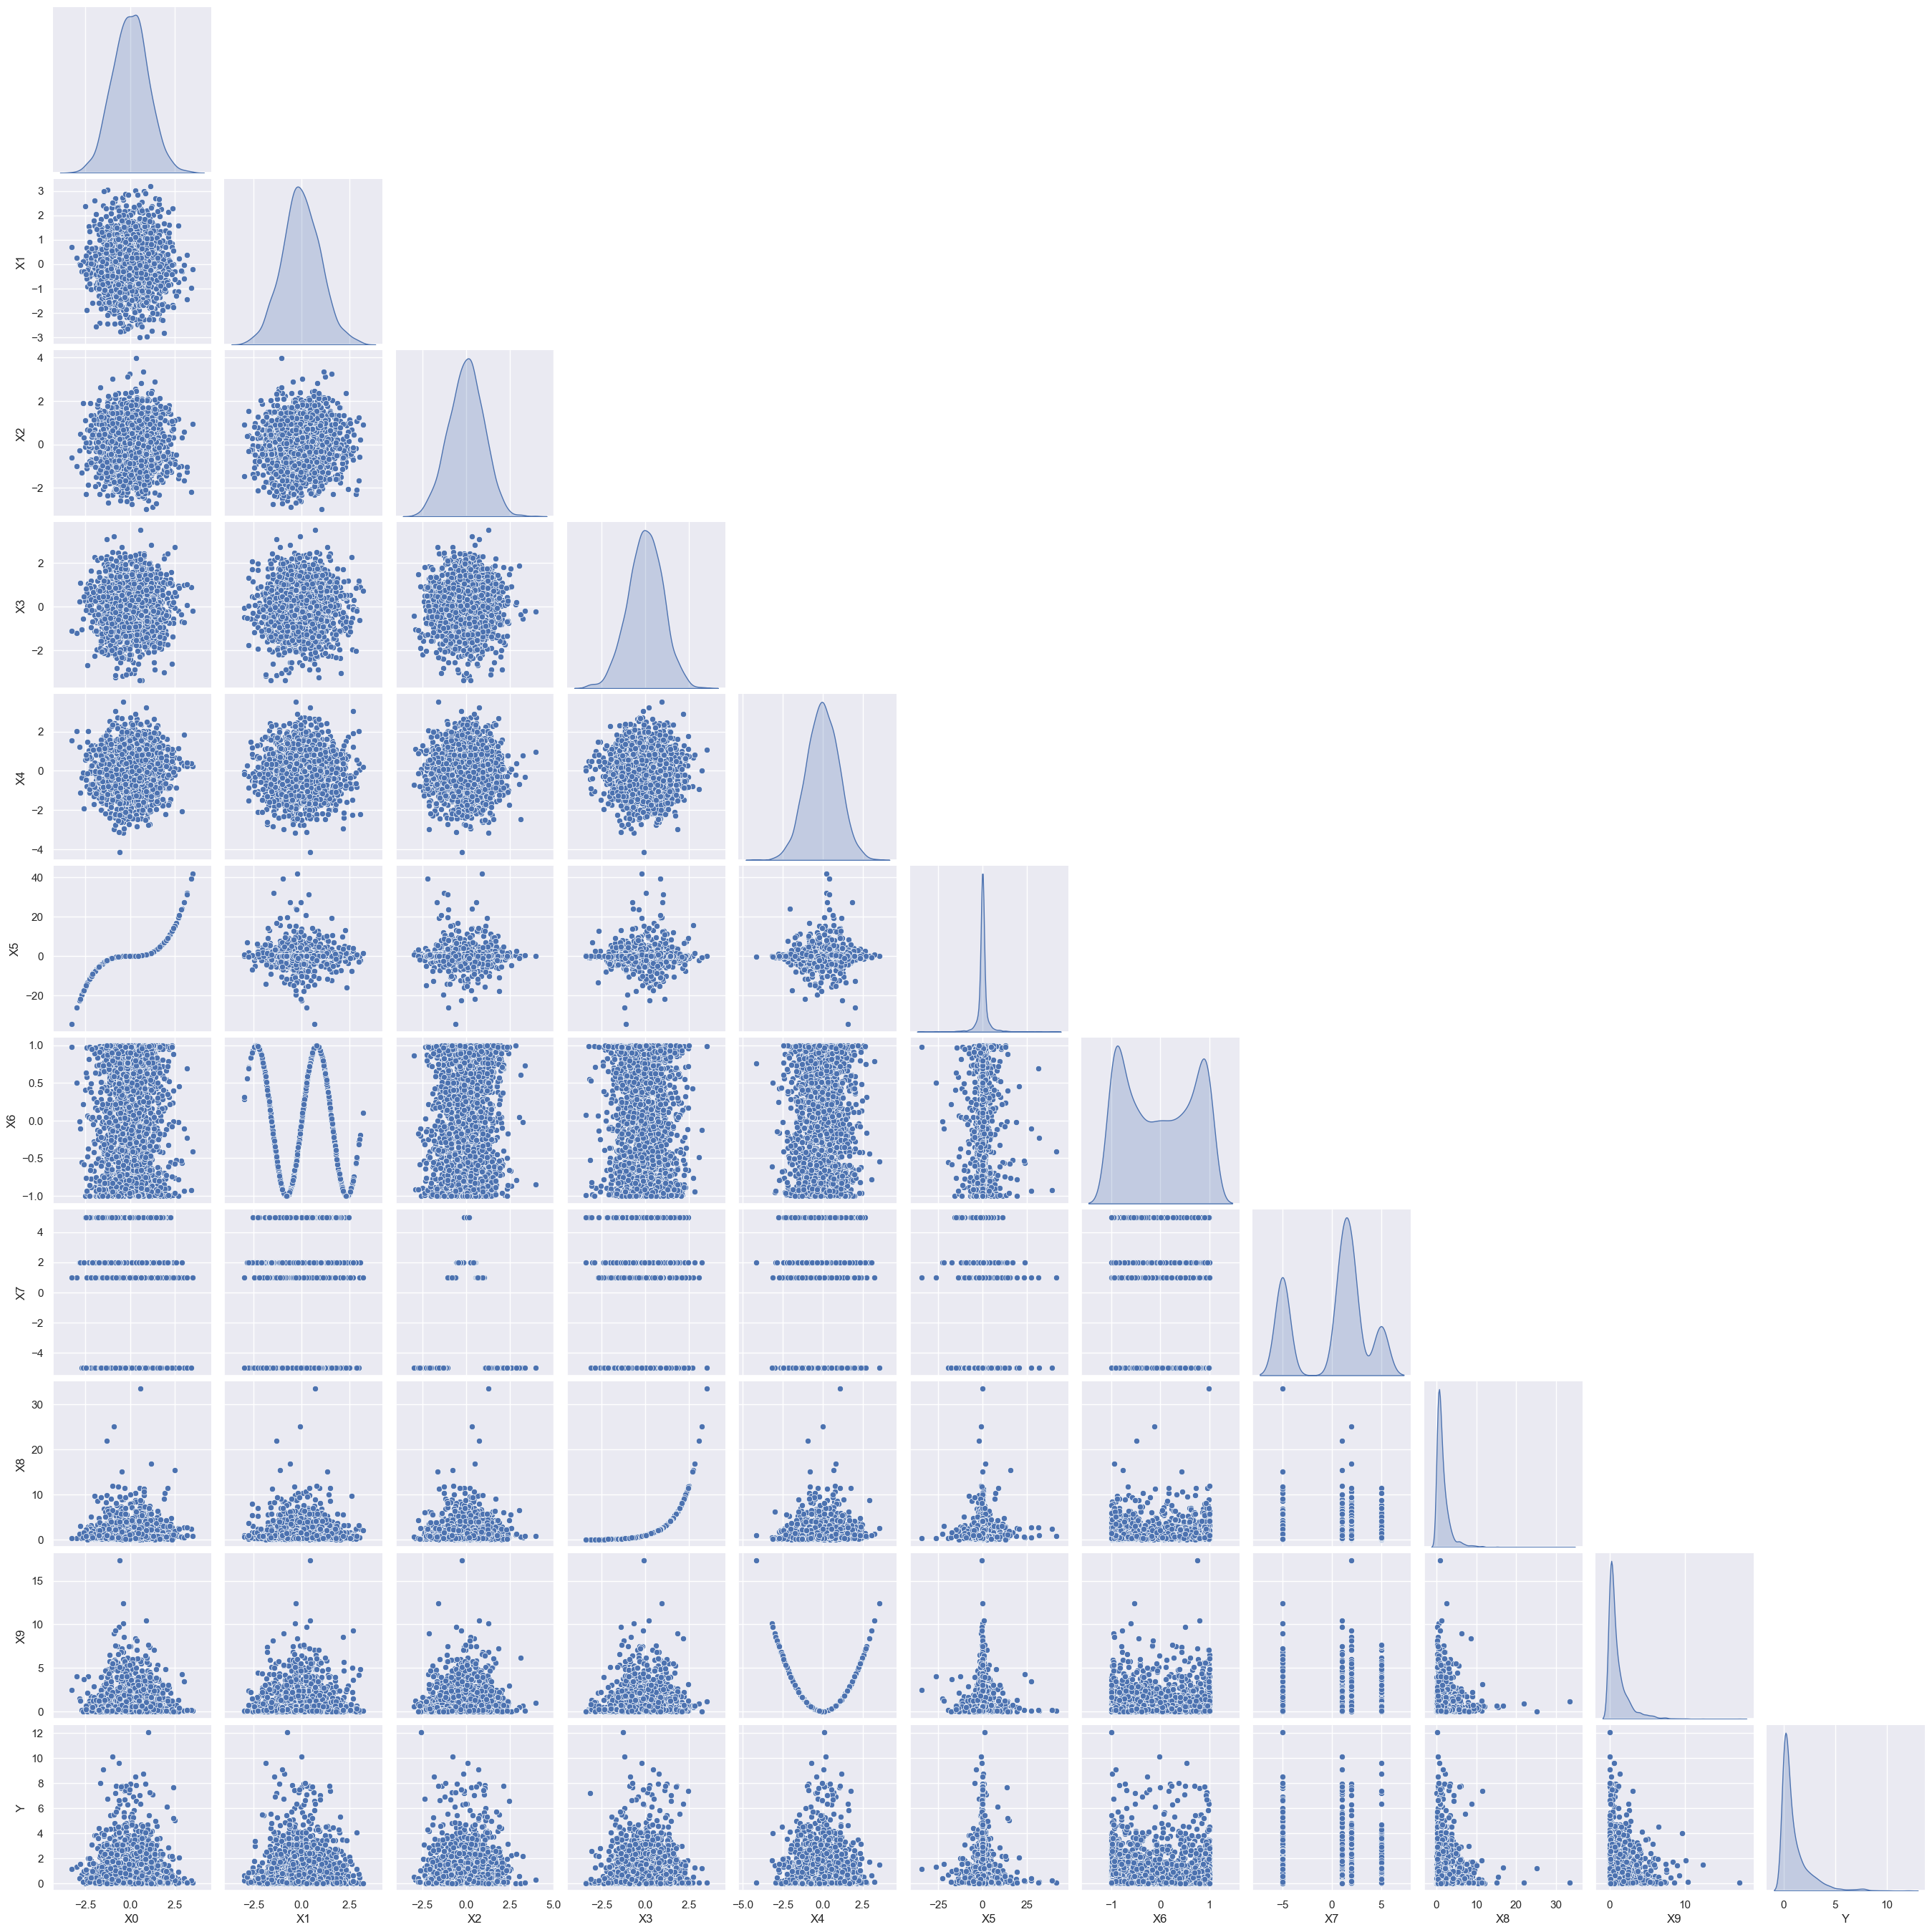

In [18]:
n = 2000

def generation_data(n, graine = np.random.randint(1000),s=0):
    np.random.seed(graine)
    X0 = np.random.normal(0,1,n)
    X1 = np.random.normal(0,1,n)
    X2 = np.random.normal(0,1,n)
    X3 = np.random.normal(0,1,n)
    X4 = np.random.normal(0,1,n)
    X5 = np.random.normal(X0**3,s*3)
    X6 = np.random.normal(np.sin(X1*2),s/5)
    k=7
    quantiles = np.percentile(X2, np.linspace(0, 100, k+1))
    levels = [-5, 1, 2,5,2,1,-5]
    X7 = np.zeros_like(X2)
    for i in range(k):
        mask = (X2 >= quantiles[i]) & (X2 <= quantiles[i+1])
        X7[mask] = levels[i] 
    X7 = np.random.normal(X7,s/10)
    X8 = np.random.normal(np.exp(X3),s)
    X9 = np.random.normal(X4**2,s)
    Y = np.random.normal(0,1,n)**2
    return pd.DataFrame(data={'X0': X0,'X1': X1,'X2': X2,'X3': X3,'X4': X4,'X5': X5,
                           'X6': X6,'X7': X7,'X8': X8,'X9': X9,'Y':Y})

data = generation_data(n,s=0)
# Reference Correlation Matrix (pairwise)
MC_ref = np.diag(np.repeat(1,data.shape[1])) 
MC_ref[0,5]=MC_ref[5,0]=1
MC_ref[1,6]=MC_ref[6,1]=1
MC_ref[2,7]=MC_ref[7,2]=1
MC_ref[3,8]=MC_ref[8,3]=1
MC_ref[4,9]=MC_ref[9,4]=1
sns.heatmap(MC_ref,annot=True, cmap="Greens")
sns.pairplot(data,diag_kind='kde', corner=True)

In [19]:
colnames = data.columns
scaler = MinMaxScaler()
data = pd.DataFrame(scaler.fit_transform(data))
data.columns = colnames

<Axes: >

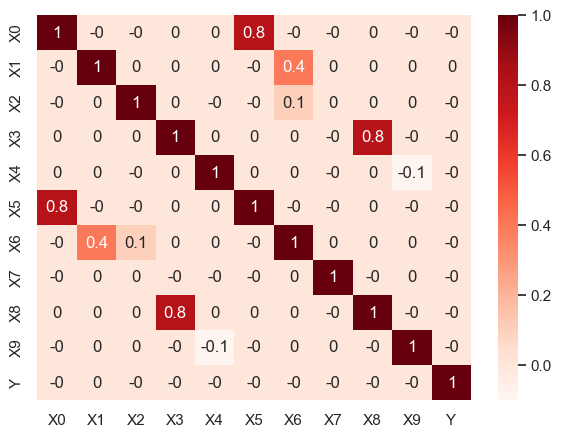

In [20]:
sns.heatmap(np.round(data.corr(method="pearson", numeric_only=True),1),annot=True, cmap="Reds")

<Axes: >

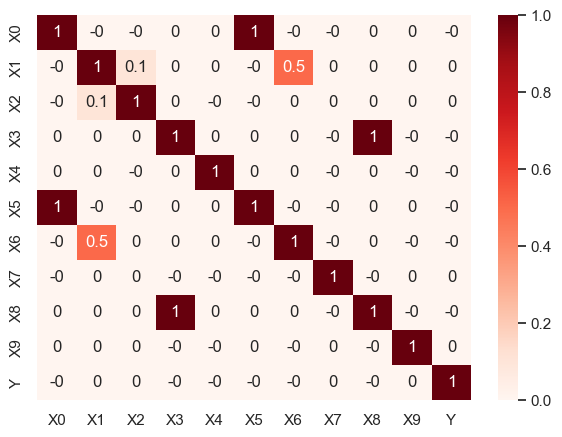

In [21]:
sns.heatmap(np.round(data.corr(method="spearman", numeric_only=True),1),annot=True, cmap="Reds")

### Data Config.

In [22]:
labY = 'Y'

In [23]:
colY = np.where(data.columns==labY)[0][0];colY

10

# SHGR Illustration

## SHGR Pairwise

In [42]:
assoc = SHGR_P(data)

Proving P=NP:  24%|██████████████▉                                               | 24/100 [00:14<00:46,  1.65carrots/s]

Early stopping triggered. Training stopped.


<Axes: >

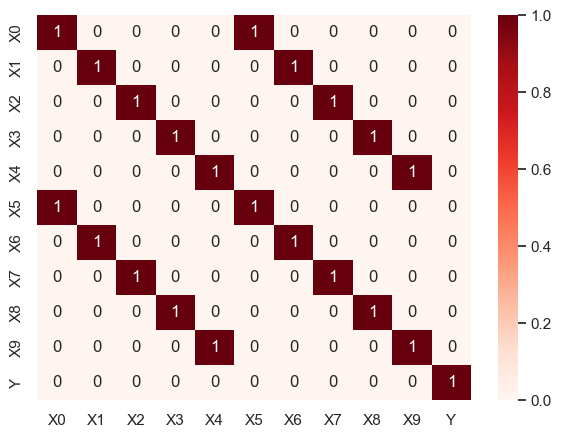

In [43]:
sns.heatmap(np.round(assoc,1),annot=True, cmap="Reds")

In [26]:
assoc = SHGR_P(data,max_patience=None) # without early stopping

Proving P=NP: 100%|█████████████████████████████████████████████████████████████| 100/100 [01:01<00:00,  1.62carrots/s]


<Axes: >

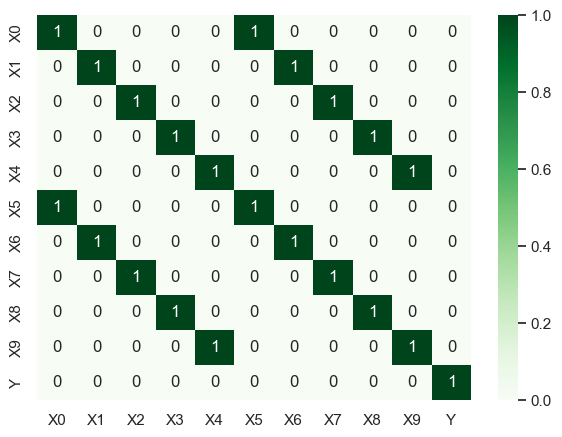

In [27]:
sns.heatmap(np.round(assoc,1),annot=True, cmap="Greens")

## Graphical analysis of SHGR transformations

In [28]:
res_HGR = train_SHGRp(np.array(data))

Proving P=NP:  24%|██████████████▉                                               | 24/100 [00:15<00:48,  1.56carrots/s]

Early stopping triggered. Training stopped.


In [29]:
model_HGR, encoded_HGR, losses_HGR, losses_inputs, best_epoch = res_HGR
encoded_HGR = pd.DataFrame(encoded_HGR.detach().cpu().numpy())

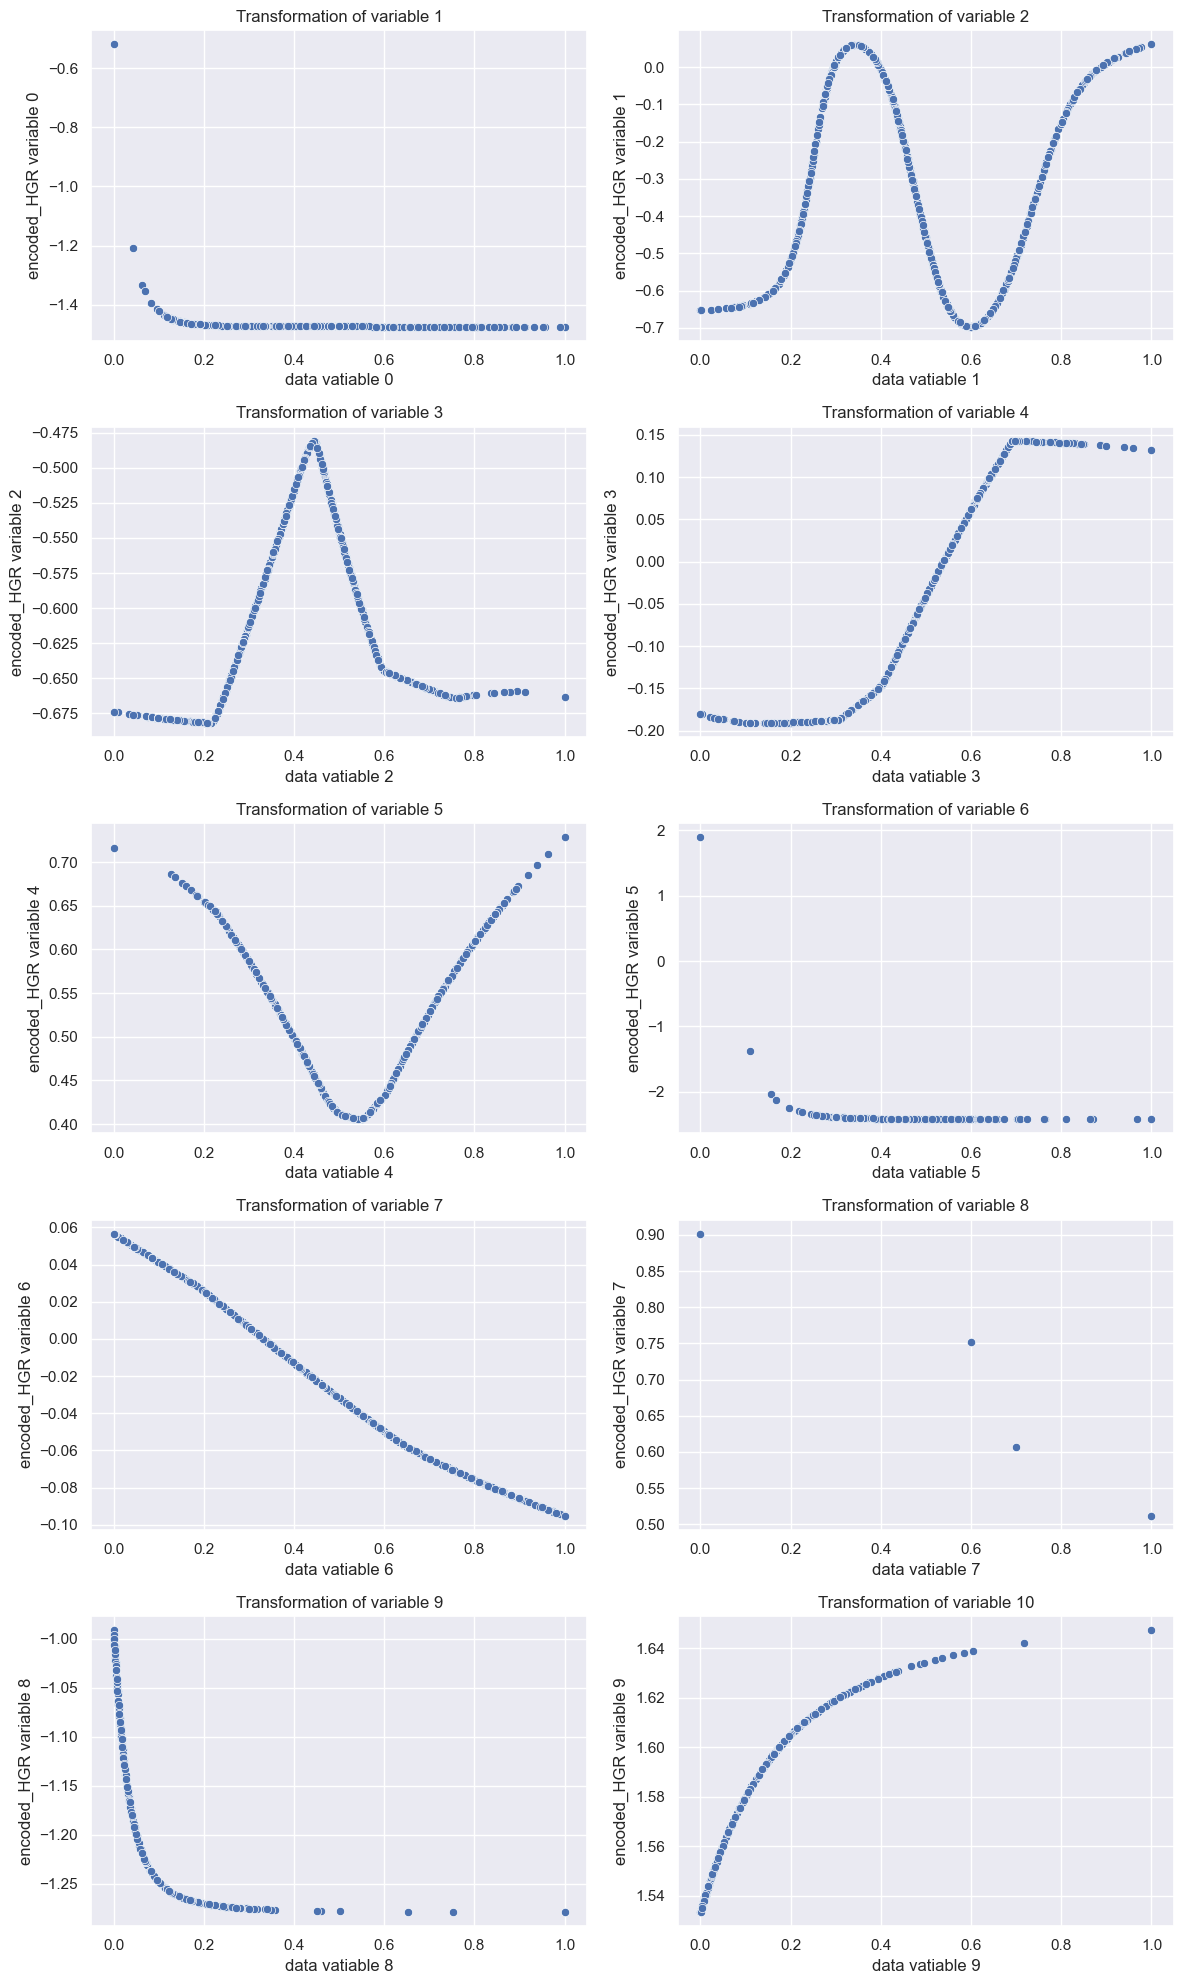

In [30]:
fig, axes = plt.subplots(5, 2, figsize=(12, 20))
axes = axes.flatten()

for i in range(data.shape[1]-1):
    sns.scatterplot(x=data.iloc[:, i], y=encoded_HGR.iloc[:, i], ax=axes[i])
    axes[i].set_title(f"Transformation of variable {i+1}")
    axes[i].set_xlabel(f"data vatiable {i}")
    axes[i].set_ylabel(f"encoded_HGR variable {i}")

plt.tight_layout()

## SHGR Multivariate

**Correlation between $X_i$ and other features**

In [31]:
assoc = SHGR_M(data)

Proving P=NP:  26%|████████████████                                              | 26/100 [00:31<01:30,  1.22s/carrots]

Early stopping triggered. Training stopped.


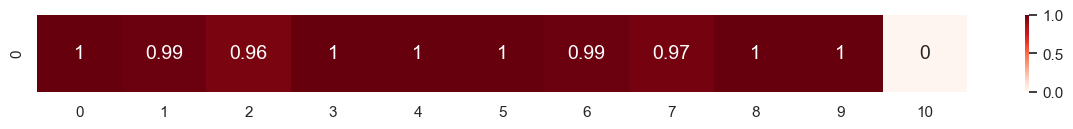

In [32]:
ax = sns.heatmap(np.round(assoc.reshape(1, -1),2),annot=True, cmap="Reds",annot_kws={"size": 14})
ax.figure.set_size_inches(15, 1)

## SHGR Groupwise

In [33]:
SHGR_F(data, data)

Proving P=NP:  20%|████████████▍                                                 | 20/100 [00:05<00:23,  3.47carrots/s]

Early stopping triggered. Training stopped.


0.9999792849948212

In [35]:
SHGR_F(generation_data(n,s=0, graine=123),data)

Proving P=NP:  19%|███████████▊                                                  | 19/100 [00:04<00:18,  4.32carrots/s]

Early stopping triggered. Training stopped.


0.05553817808463712

## Contribution

**Contribution of $X_j$ on Correlation between  a target $X_i$ and others features**

In [36]:
Ctr_ = Contrib_M(data,0)
Ctr_

Proving P=NP:  26%|████████████████                                              | 26/100 [00:32<01:32,  1.25s/carrots]


Early stopping triggered. Training stopped.


Proving P=NP:  25%|███████████████▌                                              | 25/100 [00:30<01:31,  1.22s/carrots]

Early stopping triggered. Training stopped.


array([ 4.1212440e-03, -1.4720559e-03,  6.6677451e-02, -2.1200776e-03,
        9.9695832e-01, -2.1906495e-03,  1.1941612e-02, -1.2925267e-03,
       -8.3309412e-04, -1.1408925e-03], dtype=float32)

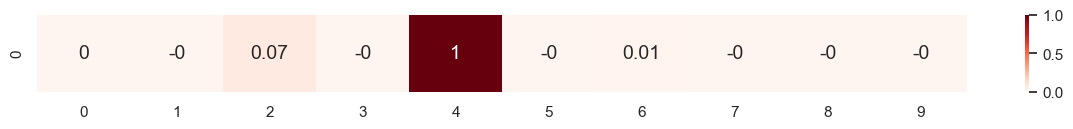

In [37]:
ax = sns.heatmap(np.round(Ctr_.reshape(1,-1),2),annot=True, cmap="Reds",annot_kws={"size": 14})
ax.figure.set_size_inches(15, 1)

## Benchmark

In [38]:
assoc = MaxCorr_P(data) #bivariate

<Axes: >

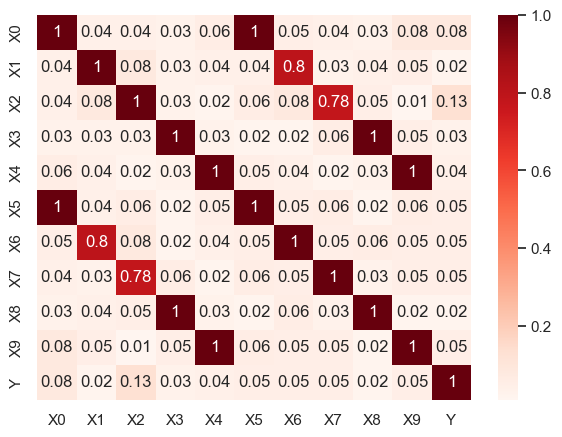

In [39]:
sns.heatmap(np.round(assoc,2),annot=True, cmap="Reds")

In [40]:
assoc = MaxCorr_M(data) #multivariate

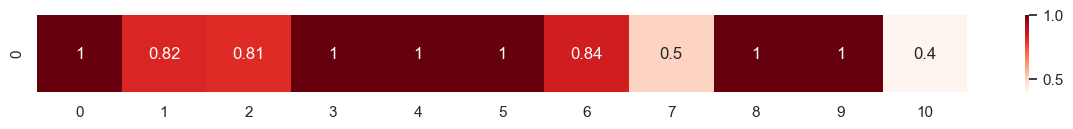

In [41]:
ax = sns.heatmap(np.round(assoc.T,2),annot=True, cmap="Reds")
ax.figure.set_size_inches(15, 1)